In [7]:
import pandas as pd
import json
from matplotlib import pyplot as plt
import geopandas as gpd
import numpy as np

In [8]:
df = pd.read_csv('cholesterol.csv')
indicators = df['IndicatorCode'].unique()
print(indicators)
df

<StringArray>
['NCD_CHOL_MEANTOTALCHOL_A',    'NCD_CHOL_MEANNONHDL_A',
       'NCD_CHOL_MEANHDL_A',         'NCD_CCS_CHOL_SVY']
Length: 4, dtype: str


,ParentLocationCode,SpatialDim,Dim1,Value,NumericValue,Date,IndicatorCode
0,AFR,SEN,SEX_FMLE,4.1 [3.6-4.5],4.1,2021-06-21T18:48:53+02:00,NCD_CHOL_MEANTOTALCHOL_A
1,AMR,PAN,SEX_BTSX,4.8 [4.6-5.1],4.8,2021-06-21T19:03:17+02:00,NCD_CHOL_MEANTOTALCHOL_A
2,EUR,PRT,SEX_BTSX,5.1 [4.9-5.3],5.1,2021-06-21T19:02:55+02:00,NCD_CHOL_MEANTOTALCHOL_A
3,WPR,NRU,SEX_MLE,4.3 [3.8-4.9],4.3,2021-06-21T18:28:09+02:00,NCD_CHOL_MEANTOTALCHOL_A
4,AMR,CAN,SEX_FMLE,5.4 [5.2-5.6],5.4,2021-06-21T18:45:26+02:00,NCD_CHOL_MEANTOTALCHOL_A
...,...,...,...,...,...,...,...
71091,AMR,HND,NaN,No,NaN,2022-04-25T15:23:43+02:00,NCD_CCS_CHOL_SVY
71092,AMR,DMA,NaN,No,NaN,2022-04-25T15:23:43+02:00,NCD_CCS_CHOL_SVY
71093,AFR,ZAF,NaN,Yes,NaN,2022-04-25T15:23:45+02:00,NCD_CCS_CHOL_SVY
71094,WPR,FJI,NaN,No,NaN,2022-04-25T15:23:43+02:00,NCD_CCS_CHOL_SVY


In [9]:
# remove null value
print(len(df))
df=df.dropna(subset=['NumericValue'])
print(len(df))
print(df["NumericValue"].isnull().sum())

71096
70902
0


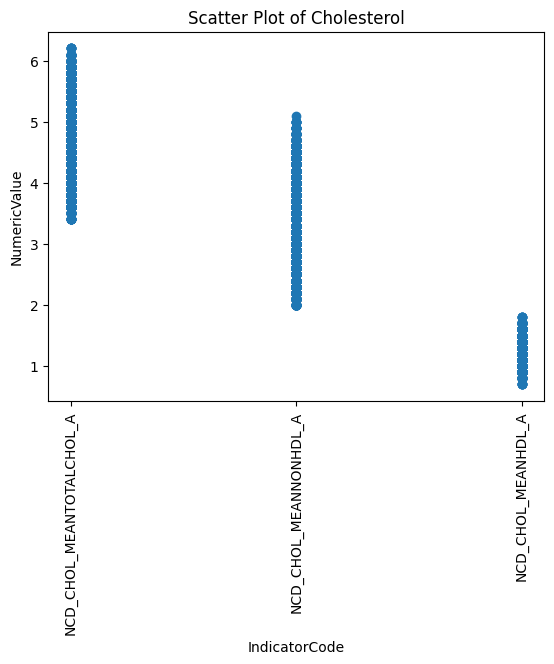

In [10]:
plt.figure()
plt.scatter(df['IndicatorCode'], df['NumericValue'])
plt.xlabel('IndicatorCode')
plt.ylabel('NumericValue')
plt.title('Scatter Plot of Cholesterol')
plt.xticks(rotation=90)
plt.show()


C:\Users\Admin\AppData\Local\Temp\ipykernel_3448\2890682797.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=codes)


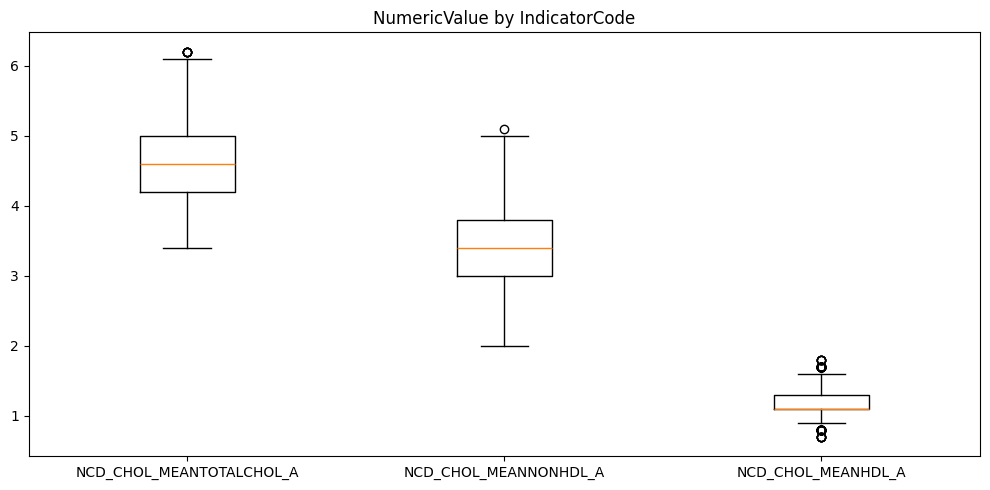

In [11]:
plt.figure(figsize=(10,5))

codes = df['IndicatorCode'].unique()
data = [df[df['IndicatorCode'] == c]['NumericValue'] for c in codes]

plt.boxplot(data, labels=codes)
#plt.xticks(rotation=45)
plt.title('NumericValue by IndicatorCode')
plt.tight_layout()
plt.show()


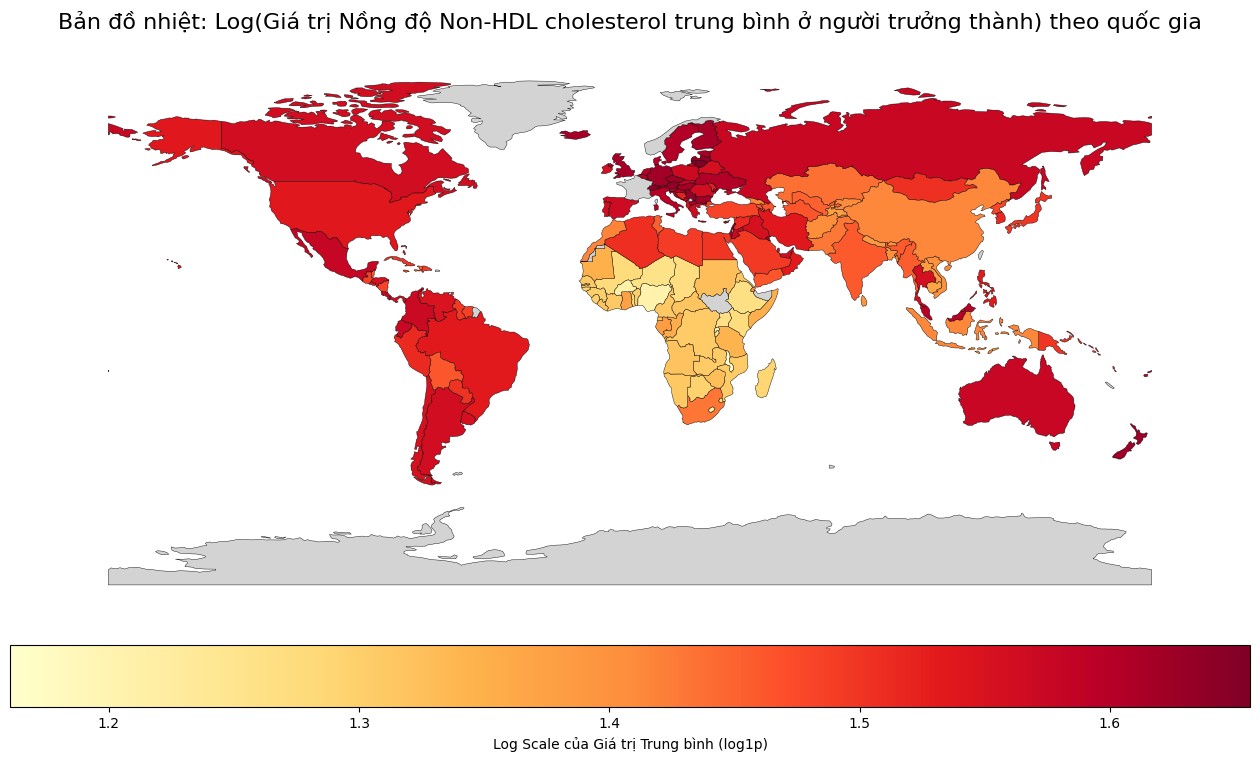

In [13]:
# ==============================
# 1. KIỂM TRA & CHUẨN HÓA (Đã sửa lỗi Mixed Timezones)
# ==============================
df1 = df[df['IndicatorCode'] == 'NCD_CHOL_MEANNONHDL_A']
df1["NumericValue"] = pd.to_numeric(df1["NumericValue"], errors="coerce")

# Thêm utc=True để xử lý các múi giờ khác nhau
df1["Date"] = pd.to_datetime(df1["Date"], errors="coerce", utc=True)

# ==============================
# 2. GỘP DỮ LIỆU & TÍNH LOG
# ==============================
df_grouped = (
    df1.groupby(
        ["SpatialDim", "ParentLocationCode"],
        as_index=False
    )
    .agg(
        MeanValue=("NumericValue", "mean"),
        Count=("NumericValue", "count")
    )
)

# Tạo cột LogMeanValue: log1p(x) = log(1 + x)
# Việc cộng 1 giúp tránh lỗi nếu MeanValue bằng 0
df_grouped["LogMeanValue"] = np.log1p(df_grouped["MeanValue"])

# ==============================
# 3. LOAD BẢN ĐỒ & MERGE
# ==============================
world = gpd.read_file("D:/FPTU/SP26/ADY201m/semantic analysis/ne_110m_admin_0_countries/ne_110m_admin_0_countries.shp")

gdf = world.merge(
    df_grouped,
    how="left",
    left_on="ISO_A3",
    right_on="SpatialDim"
)

# ==============================
# 4. VẼ BẢN ĐỒ VỚI THANG LOG
# ==============================
fig, ax = plt.subplots(figsize=(16, 9))

# Sử dụng cột "LogMeanValue" để vẽ màu
gdf.plot(
    column="LogMeanValue", 
    ax=ax,
    legend=True,
    cmap="YlOrRd",
    edgecolor="black",
    linewidth=0.3,
    legend_kwds={
        'label': "Log Scale của Giá trị Trung bình (log1p)",
        'orientation': "horizontal",
        'pad': 0.05
    },
    missing_kwds={
        "color": "lightgrey",
        "label": "No data"
    }
)

ax.set_title(
    "Bản đồ nhiệt: Log(Giá trị Nồng độ Non-HDL cholesterol trung bình ở người trưởng thành) theo quốc gia", 
    fontsize=16, 
    pad=20
)

ax.axis("off")
plt.show()